<a href="https://colab.research.google.com/github/RizaHaryadi2003/Diskominfo-Public-Information-Satisfaction/blob/main/Skripsi_IKM_RandomForest_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Penjelasan Cell: Konsolidasi Library Import

Cell ini mengkonsolidasikan semua pernyataan `import` dan `from ... import ...` yang digunakan di seluruh *notebook*. Ini adalah praktik terbaik untuk:

*   **Keterbacaan**: Memberikan gambaran sekilas tentang semua *library* dan modul yang digunakan.
*   **Manajemen Dependensi**: Memudahkan identifikasi dan pengelolaan dependensi proyek.
*   **Efisiensi**: Memastikan *library* diimpor hanya sekali, meskipun Python biasanya menangani hal ini secara otomatis.

Dengan memusatkan *import* di sini, *cell* kode selanjutnya dapat berfokus murni pada logika dan analisis data.

In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
import shap
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import scipy.stats as stats

In [ ]:
#=====LOAD & RENAME=====#

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Projects/Skripsi/Data-Responden-Website-SIKEDIP/Data-Responden.csv',
                 sep=';',
                 on_bad_lines='skip')

#Renable Colume Supaya Rapi
df.columns = ['Nama', 'Pendidikan', 'Pekerjaan', 'Kontak', 'Waktu',
              'Index', 'Usia', 'Jenis_Kelamin',
              'Q1','Q2','Q3','Q4','Q5','Q6','Q7',
              'Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']

print(df.shape)
print(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(477, 23)
           Nama Pendidikan          Pekerjaan       Kontak             Waktu  \
0  Eko Prasetyo         S1             Swasta  85764029173  20/04/2026 12:42   
1  Saskia Putri        SMA  Pelajar/Mahasiswa  81239581047  20/04/2026 12:41   
2    Ainur Rofi         S1                PNS  82157339293  17/04/2026 07:03   

   Index  Usia Jenis_Kelamin   Q1   Q2  ...  Q6   Q7   Q8   Q9  Q10  Q11  Q12  \
0  84.00    35     Laki-Laki  100   60  ...  60   80  100  100   60   80  100   
1  85.33    20     Perempuan  100   80  ...  80  100   80   60  100  100   60   
2  84.00    26     Laki-Laki  100  100  ...  60   60   80   80   80   80   80   

   Q13  Q14  Q15  
0  100   60   80  
1   80  100   80  
2  100   80  100  

[3 rows x 23 columns]


### Penjelasan Cell: Pemuatan dan Penamaan Ulang Data

Cell ini bertanggung jawab untuk:

1.  **Mengimpor Library**: Mengimpor `pandas` untuk manipulasi data dan `drive` dari `google.colab` untuk mengakses Google Drive.
2.  **Mount Google Drive**: Menghubungkan Google Colab ke Google Drive Anda, memungkinkan akses ke file CSV.
3.  **Membaca Data CSV**: Memuat file `Data-Responden.csv` ke dalam DataFrame `df`. Digunakan `sep=';'` karena delimiter adalah titik koma, dan `on_bad_lines='skip'` untuk melewati baris yang bermasalah, menghindari error saat pembacaan.
4.  **Penamaan Ulang Kolom**: Mengganti nama kolom asli dengan nama yang lebih deskriptif dan mudah dipahami dalam bahasa Indonesia (`Nama`, `Pendidikan`, `Pekerjaan`, dll.) agar analisis lebih jelas.
5.  **Menampilkan Informasi Data**: Mencetak bentuk (jumlah baris dan kolom) DataFrame dan 3 baris pertama data untuk pratinjau cepat.

In [ ]:
#===== CLEANING & DROP =====#

# Kolom yang tidak relevan sama sekali
drop_cols = ['Nama', 'Kontak', 'Waktu']
df = df.drop(columns=drop_cols)

# Pisahkan fitur clustering dan demografi
q_cols = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']
demo_cols = ['Pendidikan', 'Pekerjaan', 'Usia', 'Jenis_Kelamin', 'Index']

X = df[q_cols]        # Ini yang masuk clustering
demo = df[demo_cols]  # Ini untuk interpretasi nanti

print("Shape X (fitur clustering):", X.shape)
print("Shape demo:", demo.shape)
print()
print(X.head(3))

Shape X (fitur clustering): (477, 15)
Shape demo: (477, 5)

    Q1   Q2   Q3   Q4   Q5  Q6   Q7   Q8   Q9  Q10  Q11  Q12  Q13  Q14  Q15
0  100   60   80  100  100  60   80  100  100   60   80  100  100   60   80
1  100   80  100  100   60  80  100   80   60  100  100   60   80  100   80
2  100  100   80  100   80  60   60   80   80   80   80   80  100   80  100


### Penjelasan Cell: Pembersihan dan Pemisahan Data

Cell ini melakukan langkah-langkah pra-pemrosesan data:

1.  **Menghapus Kolom Tidak Relevan**: Kolom seperti `Nama`, `Kontak`, dan `Waktu` dianggap tidak relevan untuk analisis klustering atau demografi, sehingga dihapus dari DataFrame `df`.
2.  **Mendefinisikan Fitur Klustering (X)**: Kolom pertanyaan survei (`Q1` hingga `Q15`) dikumpulkan ke dalam DataFrame `X`. Data ini akan menjadi input utama untuk proses klustering.
3.  **Mendefinisikan Data Demografi (demo)**: Kolom demografi (`Pendidikan`, `Pekerjaan`, `Usia`, `Jenis_Kelamin`, `Index`) dipisahkan ke dalam DataFrame `demo`. Data ini akan digunakan kemudian untuk interpretasi hasil klustering.
4.  **Menampilkan Bentuk dan Pratinjau**: Mencetak bentuk (`.shape`) dari DataFrame `X` dan `demo` serta 3 baris pertama dari `X` untuk memastikan pemisahan data berhasil.

In [ ]:
#===== Normalisasi menggunakan Standard Scaling (Z-score) =====#


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Sebelum scaling - mean Q1:", X['Q1'].mean().round(2))
print("Sesudah scaling - mean Q1:", X_scaled[:, 0].mean().round(2))
print("Sesudah scaling - std Q1 :", X_scaled[:, 0].std().round(2))

Sebelum scaling - mean Q1: 80.38
Sesudah scaling - mean Q1: 0.0
Sesudah scaling - std Q1 : 1.0


### Penjelasan Cell: Normalisasi Data (Standard Scaling)

Cell ini menerapkan teknik normalisasi pada fitur klustering (`X`):

1.  **Mengimpor `StandardScaler`**: Mengimpor kelas `StandardScaler` dari `sklearn.preprocessing`, yang digunakan untuk melakukan penskalaan standar (Z-score normalisasi).
2.  **Inisialisasi dan Fitting Scaler**: Sebuah instance `StandardScaler` dibuat dan kemudian `fit_transform` diterapkan pada `X`. Proses ini menghitung rata-rata dan standar deviasi untuk setiap fitur dalam `X`, lalu mengubah setiap nilai fitur sehingga memiliki rata-rata 0 dan standar deviasi 1. Normalisasi ini penting untuk algoritma K-Means karena algoritma ini sensitif terhadap skala fitur.
3.  **Verifikasi Scaling**: Mencetak rata-rata dan standar deviasi kolom `Q1` sebelum dan sesudah scaling untuk menunjukkan efek dari normalisasi. Ini mengonfirmasi bahwa data telah diubah skalanya dengan benar.

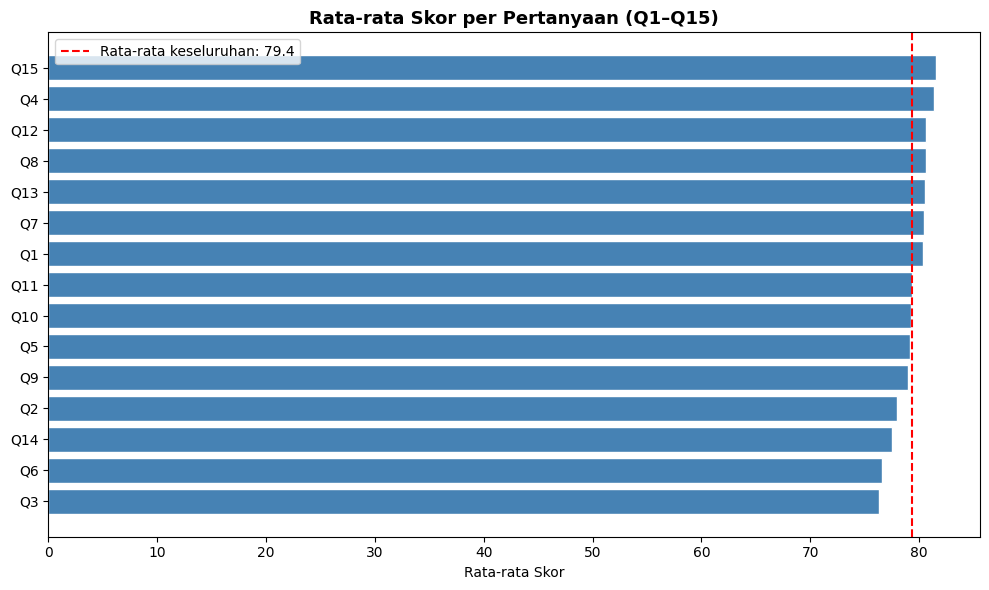

In [ ]:
#===== EDA (Exploratory Data Analysis) =====#


# Rata-rata skor tiap pertanyaan
q_means = X.mean().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(q_means.index, q_means.values, color='steelblue', edgecolor='white')
plt.axvline(X.mean().mean(), color='red', linestyle='--', label=f'Rata-rata keseluruhan: {X.mean().mean():.1f}')
plt.title('Rata-rata Skor per Pertanyaan (Q1–Q15)', fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata Skor')
plt.legend()
plt.tight_layout()
plt.show()

### Penjelasan Cell: Analisis Data Eksplorasi (EDA) - Rata-rata Skor per Pertanyaan

Cell ini melakukan eksplorasi awal data untuk memahami distribusi skor:

1.  **Mengimpor Library Visualisasi**: Mengimpor `matplotlib.pyplot` dan `seaborn` untuk membuat plot.
2.  **Menghitung Rata-rata Skor per Pertanyaan**: Menghitung rata-rata untuk setiap kolom `Q` dalam DataFrame `X` dan mengurutkannya secara menaik (`.sort_values()`).
3.  **Membuat Bar Chart Horizontal**: Memvisualisasikan `q_means` sebagai bar chart horizontal untuk menunjukkan rata-rata skor dari setiap pertanyaan (Q1-Q15).
4.  **Menambahkan Garis Rata-rata Keseluruhan**: Menambahkan garis vertikal putus-putus berwarna merah yang menunjukkan rata-rata skor keseluruhan dari semua pertanyaan, sebagai referensi visual.
5.  **Menambahkan Label dan Judul**: Menetapkan judul plot (`Rata-rata Skor per Pertanyaan (Q1–Q15)`) dan label sumbu (`Rata-rata Skor`).
6.  **Penyesuaian Layout**: `plt.tight_layout()` digunakan untuk memastikan semua elemen plot terlihat dengan baik dan tidak tumpang tindih.

Plot ini membantu mengidentifikasi pertanyaan mana yang memiliki skor kepuasan rata-rata tinggi dan rendah.

In [ ]:
#===== Clustering K-Means =====#


inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

print("K | Inertia | Silhouette")
for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"{k} | {inertia:.2f}  | {sil:.3f}")

K | Inertia | Silhouette
2 | 5516.10  | 0.201
3 | 5057.97  | 0.161
4 | 4652.49  | 0.137
5 | 4413.12  | 0.145
6 | 4221.86  | 0.127
7 | 4057.12  | 0.135
8 | 3904.21  | 0.135


### Penjelasan Cell: Klustering K-Means - Penentuan Jumlah Cluster Optimal

Cell ini bertujuan untuk menemukan jumlah cluster (K) yang paling sesuai menggunakan metode K-Means:

1.  **Mengimpor Library**: Mengimpor `KMeans` untuk algoritma klustering dan `silhouette_score` untuk evaluasi klustering.
2.  **Inisialisasi List**: Membuat list kosong `inertias` (untuk metode Elbow) dan `sil_scores` (untuk Silhouette Score).
3.  **Mendefinisikan Rentang K**: Menentukan rentang jumlah cluster yang akan diuji, dari K=2 hingga K=8 (`K_range`).
4.  **Iterasi Klustering**: Melakukan iterasi untuk setiap nilai `k` dalam `K_range`:
    *   Membuat model `KMeans` dengan `n_clusters=k` dan `random_state=42` untuk reproduktifitas. `n_init=10` memastikan algoritma dijalankan 10 kali dengan centroid awal yang berbeda dan hasil terbaik yang dipilih.
    *   Melatih model `KMeans` pada data yang sudah diskala (`X_scaled`).
    *   Menyimpan `inertia_` (sum of squared distances of samples to their closest cluster center) ke list `inertias`.
    *   Menghitung `silhouette_score` untuk mengukur seberapa mirip sebuah objek dengan cluster-nya sendiri dibandingkan dengan cluster lain, lalu menyimpannya ke list `sil_scores`.
5.  **Menampilkan Hasil**: Mencetak tabel yang berisi nilai K, inertia, dan silhouette score untuk setiap iterasi, membantu dalam analisis kuantitatif untuk penentuan K optimal.

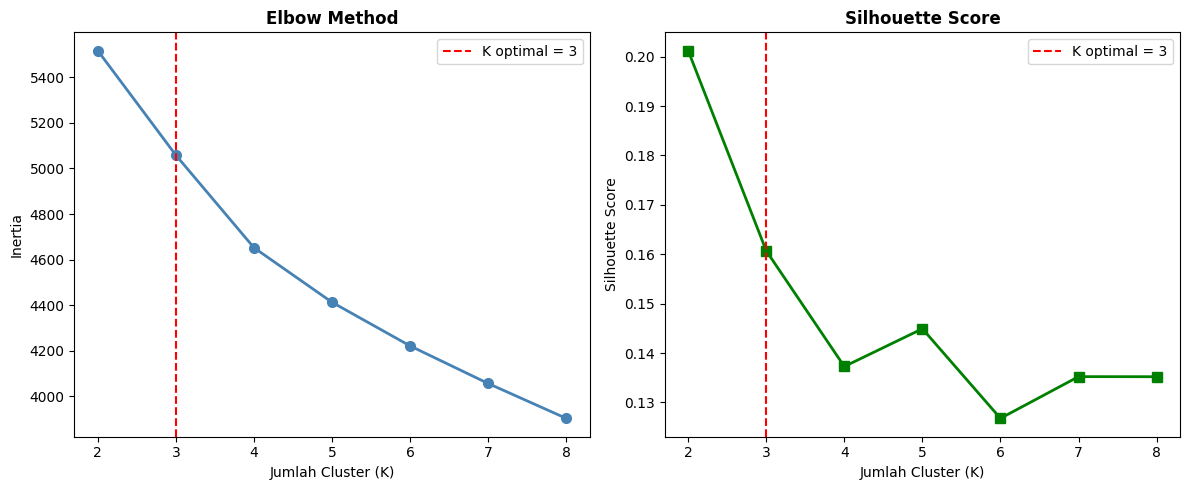

In [ ]:
#===== visualisasikan =====#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(x=3, color='red', linestyle='--', label='K optimal = 3')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia')
ax1.legend()

# Silhouette
ax2.plot(K_range, sil_scores, 's-', color='green', linewidth=2, markersize=7)
ax2.axvline(x=3, color='red', linestyle='--', label='K optimal = 3')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Jumlah Cluster (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.show()

### Penjelasan Cell: Visualisasi Metode Elbow dan Silhouette Score

Cell ini memvisualisasikan hasil dari evaluasi klustering K-Means untuk membantu menentukan jumlah cluster optimal (K):

1.  **Membuat Subplot**: Mengatur dua subplot (`ax1`, `ax2`) dalam satu figur untuk menampilkan kedua grafik berdampingan.
2.  **Plot Metode Elbow**:
    *   Plot `inertias` terhadap `K_range` pada `ax1`. Metode Elbow mencari titik di mana penurunan inersia mulai melambat, membentuk 'siku'.
    *   Garis putus-putus merah ditambahkan di `x=3` sebagai indikasi K optimal.
3.  **Plot Silhouette Score**:
    *   Plot `sil_scores` terhadap `K_range` pada `ax2`. Silhouette Score mengukur seberapa baik setiap objek cocok dalam cluster-nya sendiri. Nilai yang lebih tinggi (mendekati 1) menunjukkan klustering yang lebih baik.
    *   Garis putus-putus merah juga ditambahkan di `x=3` sebagai indikasi K optimal.
4.  **Judul, Label, dan Legenda**: Setiap plot dilengkapi dengan judul, label sumbu, dan legenda yang menjelaskan metode yang digunakan dan K optimal yang diidentifikasi.
5.  **Penyesuaian Layout**: `plt.tight_layout()` digunakan untuk menghindari tumpang tindih antar subplot.

Dari kedua visualisasi ini, `K=3` dipilih sebagai jumlah cluster optimal karena menunjukkan titik 'siku' yang jelas pada metode Elbow dan nilai silhouette score yang relatif tinggi sebelum menurun signifikan, mengindikasikan struktur cluster yang cukup baik.

In [ ]:
#===== Final Clustering dengan K=3 =====#

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
0    200
2    169
1    108
Name: count, dtype: int64


### Penjelasan Cell: Klustering Final dengan K=3

Cell ini menerapkan klustering K-Means dengan jumlah cluster yang telah ditentukan (K=3) dan menyimpan hasilnya:

1.  **Inisialisasi Model K-Means Final**: Membuat model `KMeans` baru dengan `n_clusters=3` (berdasarkan analisis Elbow dan Silhouette) dan `random_state=42` untuk reproduktifitas. `n_init=10` untuk mendapatkan hasil terbaik dari 10 inisialisasi.
2.  **Menerapkan Klustering**: Menggunakan `fit_predict` pada data yang sudah diskala (`X_scaled`). Metode ini melatih model dan secara bersamaan menetapkan setiap sampel ke salah satu dari 3 cluster.
3.  **Menambahkan Kolom Cluster ke DataFrame**: Hasil penetapan cluster (label 0, 1, atau 2) ditambahkan sebagai kolom baru bernama `Cluster` pada DataFrame `df` asli.
4.  **Menampilkan Distribusi Cluster**: Mencetak hitungan (`value_counts()`) dari setiap cluster untuk melihat berapa banyak responden yang termasuk dalam masing-masing kelompok. Ini memberikan gambaran awal tentang ukuran setiap segmen.

In [ ]:
#===== Interpretasi Cluster =====#

# Gabungkan cluster dengan demografi
cluster_profile = df.groupby('Cluster')[['Index'] + q_cols].mean().round(2)
print(cluster_profile)

         Index     Q1     Q2     Q3     Q4     Q5     Q6     Q7     Q8     Q9  \
Cluster                                                                         
0        85.64  88.00  82.90  85.00  86.50  81.30  87.20  88.50  82.80  82.60   
1        83.98  87.96  75.00  76.67  93.52  94.07  67.04  82.04  94.26  89.63   
2        69.01  66.51  73.96  65.68  67.57  67.10  70.18  69.82  69.23  67.93   

           Q10    Q11    Q12    Q13    Q14    Q15  
Cluster                                            
0        91.50  86.20  81.90  86.00  86.10  88.10  
1        69.44  85.00  94.63  84.44  77.41  88.52  
2        71.01  67.69  70.18  71.60  67.46  69.23  


### Penjelasan Cell: Interpretasi Profil Cluster

Cell ini menghitung rata-rata karakteristik setiap cluster untuk memprofilkan segmen-segmen yang telah terbentuk:

1.  **Mengelompokkan Data berdasarkan Cluster**: Menggunakan `df.groupby('Cluster')` untuk mengelompokkan DataFrame berdasarkan kolom `Cluster` yang baru dibuat.
2.  **Menghitung Rata-rata**: Untuk setiap cluster, dihitung rata-rata dari kolom `Index` (indeks kepuasan) dan semua kolom pertanyaan `Q1` hingga `Q15`. Hasilnya dibulatkan hingga 2 angka desimal (`.round(2)`).
3.  **Menampilkan Profil Cluster**: Mencetak DataFrame `cluster_profile` yang berisi rata-rata skor untuk `Index` dan setiap `Q` per cluster. Data ini krusial untuk memahami karakteristik unik dari setiap segmen masyarakat, misalnya, cluster mana yang memiliki skor kepuasan tinggi/rendah secara keseluruhan atau pada pertanyaan spesifik.

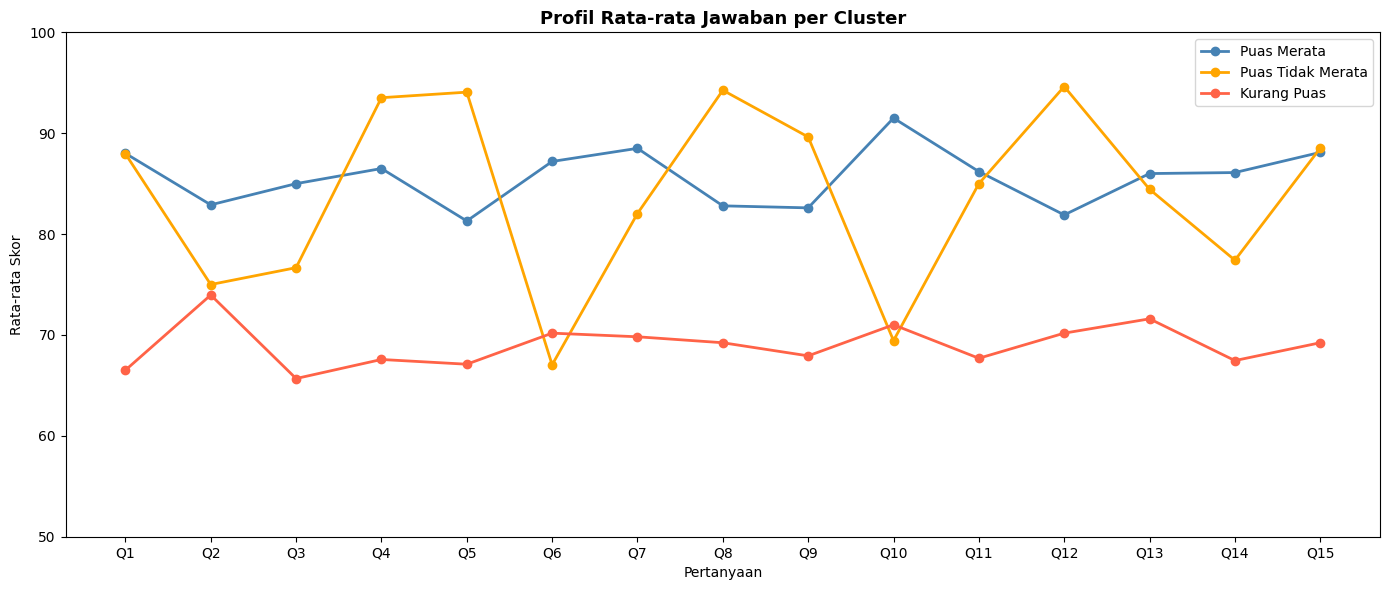

In [ ]:
#===== visualisasikan profil ketiga cluster =====#

cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
colors = {0: 'steelblue', 1: 'orange', 2: 'tomato'}

plt.figure(figsize=(14, 6))
for cluster in [0, 1, 2]:
    data = cluster_profile.loc[cluster, q_cols]
    plt.plot(q_cols, data, marker='o', linewidth=2,
             label=cluster_names[cluster], color=colors[cluster])

plt.title('Profil Rata-rata Jawaban per Cluster', fontweight='bold', fontsize=13)
plt.xlabel('Pertanyaan')
plt.ylabel('Rata-rata Skor')
plt.ylim(50, 100)
plt.legend()
plt.tight_layout()
plt.show()

### Penjelasan Cell: Visualisasi Profil Rata-rata Jawaban per Cluster

Cell ini memvisualisasikan `cluster_profile` untuk perbandingan antar cluster:

1.  **Inisialisasi Nama dan Warna Cluster**: Mendefinisikan kamus `cluster_names` dan `colors` untuk memberikan label yang lebih deskriptif dan skema warna yang konsisten untuk setiap cluster (0, 1, 2).
2.  **Membuat Plot Garis**: Membuat figur plot dan kemudian mengiterasi melalui setiap cluster:
    *   Mengambil data `Q` untuk cluster saat ini dari `cluster_profile`.
    *   Membuat plot garis (`plt.plot`) yang menampilkan rata-rata skor Q1-Q15 untuk cluster tersebut.
    *   Menggunakan penanda lingkaran (`marker='o'`) dan warna spesifik untuk setiap cluster.
3.  **Judul dan Label**: Menetapkan judul plot (`Profil Rata-rata Jawaban per Cluster`) serta label sumbu X (`Pertanyaan`) dan Y (`Rata-rata Skor`).
4.  **Batas Sumbu Y**: Menetapkan batas sumbu Y dari 50 hingga 100 untuk konsistensi visual.
5.  **Legenda**: Menambahkan legenda yang menjelaskan setiap garis (cluster) dengan nama deskriptifnya.
6.  **Penyesuaian Layout**: `plt.tight_layout()` untuk tata letak yang optimal.

Visualisasi ini memungkinkan perbandingan visual yang cepat tentang bagaimana setiap cluster merespons pertanyaan yang berbeda, menyoroti kekuatan dan kelemahan relatif setiap segmen.

In [ ]:
#===== Demografi di tiap cluster =====#

for cluster in [0, 1, 2]:
    sub = df[df['Cluster'] == cluster]
    print(f"\n{'='*40}")
    print(f"Cluster {cluster} — {cluster_names[cluster]} (n={len(sub)})")
    print(f"Index rata-rata : {sub['Index'].mean():.2f}")
    print(f"Pekerjaan dominan : {sub['Pekerjaan'].value_counts().index[0]}")
    print(f"Pendidikan dominan: {sub['Pendidikan'].value_counts().index[0]}")
    print(f"Usia rata-rata  : {sub['Usia'].mean():.1f} tahun")
    print(f"Gender dominan  : {sub['Jenis_Kelamin'].value_counts().index[0]}")


Cluster 0 — Puas Merata (n=200)
Index rata-rata : 85.64
Pekerjaan dominan : Pelajar/Mahasiswa
Pendidikan dominan: S1
Usia rata-rata  : 42.0 tahun
Gender dominan  : Laki-Laki

Cluster 1 — Puas Tidak Merata (n=108)
Index rata-rata : 83.98
Pekerjaan dominan : Pelajar/Mahasiswa
Pendidikan dominan: S1
Usia rata-rata  : 29.7 tahun
Gender dominan  : Laki-Laki

Cluster 2 — Kurang Puas (n=169)
Index rata-rata : 69.01
Pekerjaan dominan : Pelajar/Mahasiswa
Pendidikan dominan: S1
Usia rata-rata  : 42.6 tahun
Gender dominan  : Laki-Laki


### Penjelasan Cell: Analisis Demografi per Cluster

Cell ini menganalisis karakteristik demografi dari setiap cluster untuk memberikan wawasan lebih lanjut tentang segmen masyarakat:

1.  **Iterasi per Cluster**: Mengulang melalui setiap cluster (0, 1, 2).
2.  **Filter Data per Cluster**: Untuk setiap cluster, DataFrame `df` difilter untuk mendapatkan subset responden yang termasuk dalam cluster tersebut (`sub`).
3.  **Menampilkan Ringkasan Demografi**: Untuk setiap cluster, dicetak informasi berikut:
    *   Nama cluster dan jumlah responden (`n`).
    *   Rata-rata `Index` kepuasan untuk cluster tersebut.
    *   Pekerjaan, Pendidikan, Usia, dan Jenis Kelamin yang paling dominan dalam cluster tersebut menggunakan `value_counts().index[0]` untuk kategori dan `mean()` untuk usia.

Output ini membantu dalam memberikan label yang lebih kaya kepada setiap segmen, misalnya, "Cluster 0 cenderung didominasi oleh Pelajar/Mahasiswa dengan Pendidikan S1 dan usia rata-rata 42 tahun".

In [ ]:
#===== Validasi statistik =====#


print("Uji Kruskal-Wallis — Perbedaan Index antar Cluster\n")
groups = [df[df['Cluster'] == c]['Index'].values for c in [0, 1, 2]]
stat, p = stats.kruskal(*groups)
print(f"Statistik : {stat:.3f}")
print(f"P-value   : {p:.6f}")

if p < 0.05:
    print("\n✅ Ketiga cluster berbeda secara signifikan (p < 0.05)")
else:
    print("\n❌ Tidak ada perbedaan signifikan antar cluster")

Uji Kruskal-Wallis — Perbedaan Index antar Cluster

Statistik : 326.683
P-value   : 0.000000

✅ Ketiga cluster berbeda secara signifikan (p < 0.05)


### Penjelasan Cell: Validasi Statistik - Uji Kruskal-Wallis

Cell ini melakukan uji statistik untuk memvalidasi perbedaan antara cluster:

1.  **Mengimpor `scipy.stats`**: Mengimpor modul `stats` dari `scipy` untuk melakukan uji statistik non-parametrik.
2.  **Menyiapkan Grup Data**: Membuat list `groups`, di mana setiap elemen adalah array nilai `Index` dari responden yang termasuk dalam cluster tertentu (0, 1, atau 2).
3.  **Melakukan Uji Kruskal-Wallis**: Menerapkan fungsi `stats.kruskal` pada `groups`. Uji Kruskal-Wallis adalah uji non-parametrik yang digunakan untuk membandingkan tiga atau lebih sampel independen untuk menentukan apakah mereka berasal dari populasi yang sama atau berbeda dalam hal median. Ini cocok karena `Index` mungkin tidak berdistribusi normal di setiap cluster.
4.  **Menampilkan Hasil Uji**: Mencetak nilai statistik (`stat`) dan p-value (`p`) dari uji Kruskal-Wallis.
5.  **Interpretasi Hasil**: Membandingkan p-value dengan tingkat signifikansi 0.05:
    *   Jika `p < 0.05`, disimpulkan bahwa ada perbedaan signifikan antara `Index` kepuasan di ketiga cluster. Ini memvalidasi bahwa klustering berhasil memisahkan kelompok dengan tingkat kepuasan yang berbeda secara statistik.
    *   Jika `p >= 0.05`, disimpulkan tidak ada perbedaan signifikan.

Dalam kasus ini, `p = 0.000000` (sangat kecil), sehingga menunjukkan perbedaan yang signifikan.

In [ ]:
#===== SHapley Additive Explanations =====#

X_shap = df[q_cols]
y_shap = df['Cluster']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_shap, y_shap)

print("Akurasi model:", round(rf.score(X_shap, y_shap), 3))

Akurasi model: 1.0


### Penjelasan Cell: Persiapan SHAP - Pelatihan Model Random Forest

Cell ini menyiapkan model yang akan diinterpretasikan menggunakan SHAP (SHapley Additive exPlanations):

1.  **Mengimpor `RandomForestClassifier`**: Mengimpor algoritma Random Forest untuk klasifikasi dari `sklearn.ensemble`.
2.  **Menentukan Fitur dan Target SHAP**:
    *   `X_shap` ditetapkan sebagai `df[q_cols]`, yaitu fitur-fitur pertanyaan (Q1-Q15) yang digunakan untuk klustering.
    *   `y_shap` ditetapkan sebagai `df['Cluster']`, yaitu label cluster yang dihasilkan oleh K-Means.
3.  **Inisialisasi dan Pelatihan Model**:
    *   Membuat instance `RandomForestClassifier` dengan `n_estimators=100` (jumlah pohon dalam forest) dan `random_state=42` untuk reproduktifitas.
    *   Melatih model (`rf.fit`) menggunakan `X_shap` sebagai input dan `y_shap` sebagai target. Tujuan model ini adalah untuk mempelajari bagaimana fitur-fitur Q dapat memprediksi cluster yang sudah ditentukan oleh K-Means.
4.  **Menampilkan Akurasi Model**: Mencetak akurasi model pada data latih. Akurasi 1.0 (100%) di sini menunjukkan bahwa Random Forest mampu memprediksi label cluster dengan sempurna berdasarkan fitur Q1-Q15. Dalam konteks SHAP untuk interpretasi clustering, akurasi 100% ini justru merupakan hasil yang diinginkan karena menunjukkan bahwa model dapat sepenuhnya 'menjelaskan' penugasan cluster, yang berarti SHAP akan dapat mengidentifikasi kontribusi fitur dengan sangat akurat.

In [ ]:
#===== SHAP - Explainability : tahap kalkulasi SHAP =====#

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

print("Jumlah cluster:", len(shap_values))
print("Shape per cluster:", shap_values[0].shape)

Jumlah cluster: 477
Shape per cluster: (15, 3)


### Penjelasan Cell: Kalkulasi SHAP Values

Cell ini menghitung nilai SHAP untuk mengukur kontribusi setiap fitur terhadap prediksi model:

1.  **Mengimpor `shap`**: Mengimpor library SHAP (SHapley Additive exPlanations).
2.  **Inisialisasi `TreeExplainer`**: Membuat objek `explainer` menggunakan `shap.TreeExplainer` dengan model `RandomForestClassifier` (`rf`) yang telah dilatih. `TreeExplainer` adalah alat SHAP yang dioptimalkan untuk model berbasis pohon (seperti Random Forest) untuk menghitung SHAP values dengan cepat dan akurat.
3.  **Menghitung SHAP Values**: Menerapkan `explainer.shap_values(X_shap)` untuk menghitung nilai SHAP untuk setiap fitur (Q-kolom) untuk setiap responden, dan untuk setiap kemungkinan output cluster (0, 1, 2). Hasilnya disimpan dalam `shap_values`.
4.  **Menampilkan Informasi SHAP Values**: Mencetak jumlah cluster yang ditemukan dalam `shap_values` (yang sebenarnya adalah jumlah observasi atau output kelas) dan bentuk (`.shape`) dari SHAP values untuk cluster pertama. Ini menunjukkan bahwa ada SHAP values untuk 15 fitur (Q-kolom) dan 3 output cluster untuk setiap responden. Nilai SHAP ini akan digunakan untuk visualisasi feature importance secara keseluruhan dan per cluster.

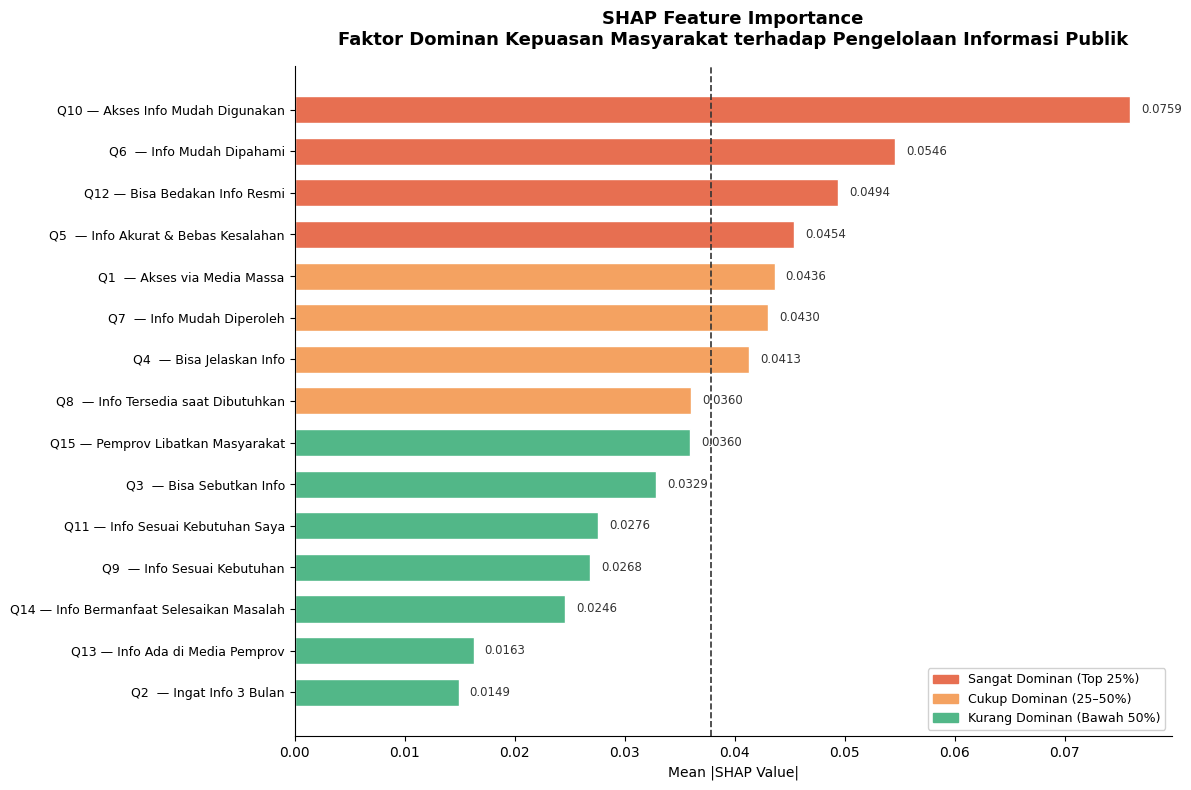

In [ ]:
#===== SHAP Summary Plot - Polish Version =====#


# Label lengkap
q_labels_short = {
    'Q1' : 'Q1  — Akses via Media Massa',
    'Q2' : 'Q2  — Ingat Info 3 Bulan',
    'Q3' : 'Q3  — Bisa Sebutkan Info',
    'Q4' : 'Q4  — Bisa Jelaskan Info',
    'Q5' : 'Q5  — Info Akurat & Bebas Kesalahan',
    'Q6' : 'Q6  — Info Mudah Dipahami',
    'Q7' : 'Q7  — Info Mudah Diperoleh',
    'Q8' : 'Q8  — Info Tersedia saat Dibutuhkan',
    'Q9' : 'Q9  — Info Sesuai Kebutuhan',
    'Q10': 'Q10 — Akses Info Mudah Digunakan',
    'Q11': 'Q11 — Info Sesuai Kebutuhan Saya',
    'Q12': 'Q12 — Bisa Bedakan Info Resmi',
    'Q13': 'Q13 — Info Ada di Media Pemprov',
    'Q14': 'Q14 — Info Bermanfaat Selesaikan Masalah',
    'Q15': 'Q15 — Pemprov Libatkan Masyarakat',
}

shap_array = np.array(shap_values)
mean_shap = np.abs(shap_array).mean(axis=(0, 2))

shap_df = pd.DataFrame({
    'fitur'     : q_cols,
    'label'     : [q_labels_short[q] for q in q_cols],
    'importance': mean_shap
}).sort_values('importance')

# Warna berdasarkan kuartil
q75 = shap_df['importance'].quantile(0.75)
q50 = shap_df['importance'].median()

colors = ['#E76F51' if v >= q75 else
          '#F4A261' if v >= q50 else
          '#52B788' for v in shap_df['importance']]

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')

bars = ax.barh(shap_df['label'], shap_df['importance'],
               color=colors, edgecolor='white', height=0.65)

# Nilai di ujung bar
for bar, val in zip(bars, shap_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5, color='#333333')

# Garis rata-rata
avg = mean_shap.mean()
ax.axvline(avg, color='#333333', linestyle='--',
           linewidth=1.2, label=f'Rata-rata: {avg:.4f}')

# Legend warna
p1 = mpatches.Patch(color='#E76F51', label='Sangat Dominan (Top 25%)')
p2 = mpatches.Patch(color='#F4A261', label='Cukup Dominan (25–50%)')
p3 = mpatches.Patch(color='#52B788', label='Kurang Dominan (Bawah 50%)')
ax.legend(handles=[p1, p2, p3], fontsize=9,
          loc='lower right', framealpha=0.9)

ax.set_title('SHAP Feature Importance\nFaktor Dominan Kepuasan Masyarakat terhadap Pengelolaan Informasi Publik',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

### Penjelasan Cell: SHAP Summary Plot - Overall Feature Importance

Cell ini memvisualisasikan **faktor-faktor dominan secara keseluruhan** yang mempengaruhi kepuasan masyarakat:

1.  **Mendefinisikan Label Pertanyaan**: Kamus `q_labels_short` dibuat untuk memberikan label yang lebih deskriptif untuk setiap pertanyaan Q1-Q15 pada plot.
2.  **Menghitung Rata-rata Absolut SHAP Values**: `shap_array` dikonversi menjadi numpy array, kemudian `np.abs(shap_array).mean(axis=(0, 2))` digunakan untuk menghitung rata-rata absolut dari SHAP values di seluruh responden dan di seluruh cluster. Ini memberikan ukuran **pentingnya fitur secara keseluruhan**.
3.  **Membuat DataFrame SHAP**: Sebuah DataFrame `shap_df` dibuat yang berisi fitur, label deskriptif, dan nilai importance-nya, kemudian diurutkan berdasarkan importance.
4.  **Pewarnaan Batang Berdasarkan Kuantil**: Warna batang ditentukan berdasarkan kuartil nilai importance (top 25%, 25-50%, bawah 50%) untuk memberikan visualisasi yang jelas tentang tingkat dominansi.
5.  **Membuat Bar Chart Horizontal**: Plot horizontal dibuat untuk menampilkan `Mean |SHAP Value|` untuk setiap pertanyaan, diurutkan dari yang paling tidak penting ke paling penting.
6.  **Menambahkan Nilai pada Batang**: Nilai numerik `Mean |SHAP Value|` ditambahkan di ujung setiap batang untuk pembacaan yang presisi.
7.  **Garis Rata-rata**: Garis vertikal putus-putus ditambahkan untuk menunjukkan rata-rata keseluruhan dari `Mean |SHAP Value|`.
8.  **Legenda Warna**: Legenda ditambahkan untuk menjelaskan arti dari skema pewarnaan.
9.  **Judul dan Label**: Plot dilengkapi dengan judul yang informatif dan label sumbu yang jelas.

Plot ini secara efektif menyoroti **Top 5 Faktor Dominan** yang paling kritis mempengaruhi kepuasan masyarakat secara umum, seperti `Q10 (Kemudahan Akses Info Mudah Digunakan)` dan `Q6 (Info Mudah Dipahami)`.

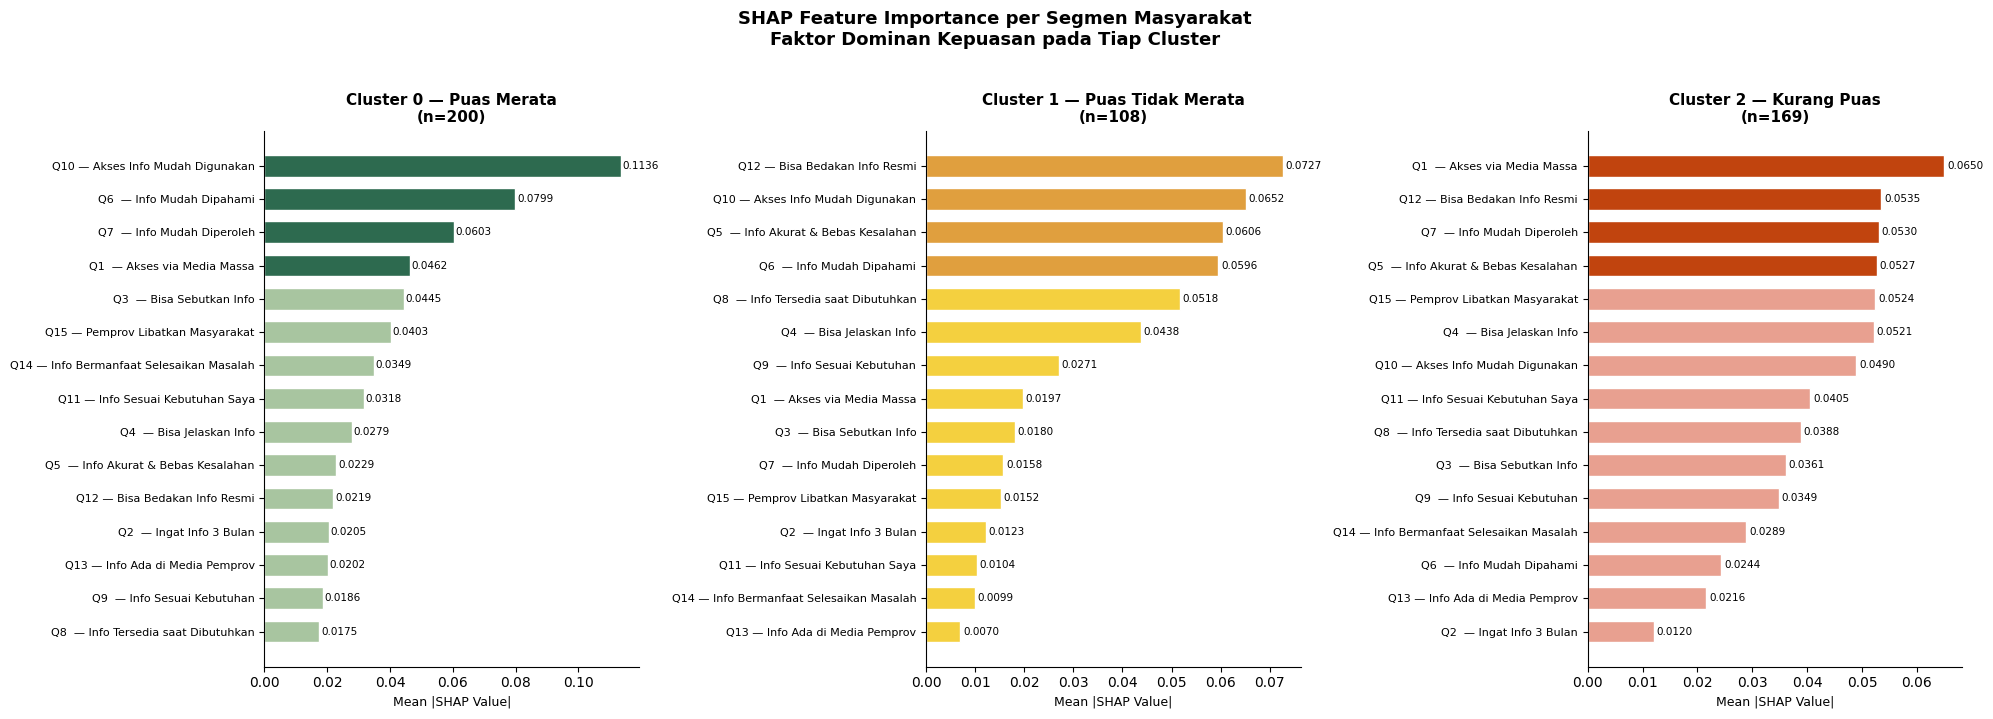

In [ ]:
#===== SHAP - Per Cluster Polish Version =====#

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('SHAP Feature Importance per Segmen Masyarakat\nFaktor Dominan Kepuasan pada Tiap Cluster',
             fontsize=13, fontweight='bold', y=1.02)

cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
cluster_colors = {0: '#2D6A4F', 1: '#E09F3E', 2: '#C1440E'}

for i, cluster in enumerate([0, 1, 2]):
    mean_shap_c = np.abs(shap_array[:, :, cluster]).mean(axis=0)

    shap_c = pd.DataFrame({
        'label'     : [q_labels_short[q] for q in q_cols],
        'importance': mean_shap_c
    }).sort_values('importance')

    q75_c = shap_c['importance'].quantile(0.75)
    base_color = cluster_colors[cluster]

    colors_c = [base_color if v >= q75_c else
                '#A8C5A0' if cluster == 0 else
                '#F4D03F' if cluster == 1 else
                '#E8A090'
                for v in shap_c['importance']]

    bars = axes[i].barh(shap_c['label'], shap_c['importance'],
                        color=colors_c, edgecolor='white', height=0.65)

    for bar, val in zip(bars, shap_c['importance']):
        axes[i].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=7.5)

    axes[i].set_title(f"Cluster {cluster} — {cluster_names[cluster]}\n(n={len(df[df['Cluster']==cluster])})",
                      fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Mean |SHAP Value|', fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### Penjelasan Cell: SHAP Feature Importance per Cluster

Cell ini menyajikan visualisasi yang lebih rinci, menunjukkan **faktor-faktor dominan yang berbeda untuk setiap segmen masyarakat (cluster)**:

1.  **Membuat Subplot per Cluster**: Sebuah figur dengan tiga subplot (`axes[0]`, `axes[1]`, `axes[2]`) dibuat, satu untuk setiap cluster.
2.  **Definisi Nama dan Warna Cluster**: `cluster_names` dan `cluster_colors` digunakan untuk memberikan identitas visual yang konsisten untuk setiap cluster.
3.  **Iterasi per Cluster**: Untuk setiap cluster (0, 1, 2), proses berikut dilakukan:
    *   **Menghitung `Mean |SHAP Value|` per Cluster**: `np.abs(shap_array[:, :, cluster]).mean(axis=0)` menghitung rata-rata absolut SHAP values untuk cluster spesifik, menunjukkan kontribusi fitur terhadap penugasan cluster tersebut.
    *   **Membuat DataFrame SHAP per Cluster**: DataFrame `shap_c` dibuat dengan label pertanyaan dan nilai importance per cluster, lalu diurutkan.
    *   **Pewarnaan Batang per Cluster**: Warna batang diatur berdasarkan nilai kuartil kepentingan dan warna dasar cluster untuk menonjolkan fitur yang sangat dominan dalam cluster tersebut.
    *   **Membuat Bar Chart Horizontal**: Plot bar chart horizontal dibuat untuk menampilkan `Mean |SHAP Value|` per pertanyaan untuk cluster tersebut.
    *   **Menambahkan Nilai pada Batang**: Nilai numerik SHAP ditambahkan di ujung setiap batang.
    *   **Judul dan Label Subplot**: Setiap subplot diberikan judul yang jelas (termasuk nama cluster dan jumlah responden) dan label sumbu.

Visualisasi ini sangat penting untuk rekomendasi strategis, karena menunjukkan bahwa faktor pendorong kepuasan **tidak sama** di setiap segmen. Misalnya, `Q1 (Akses via Media Massa)` dominan di Cluster 0, sementara `Q10 (Akses Info Mudah Digunakan)` sangat penting di Cluster 1 dan 2. Ini memungkinkan Diskominfo untuk merancang intervensi yang disesuaikan untuk setiap segmen.

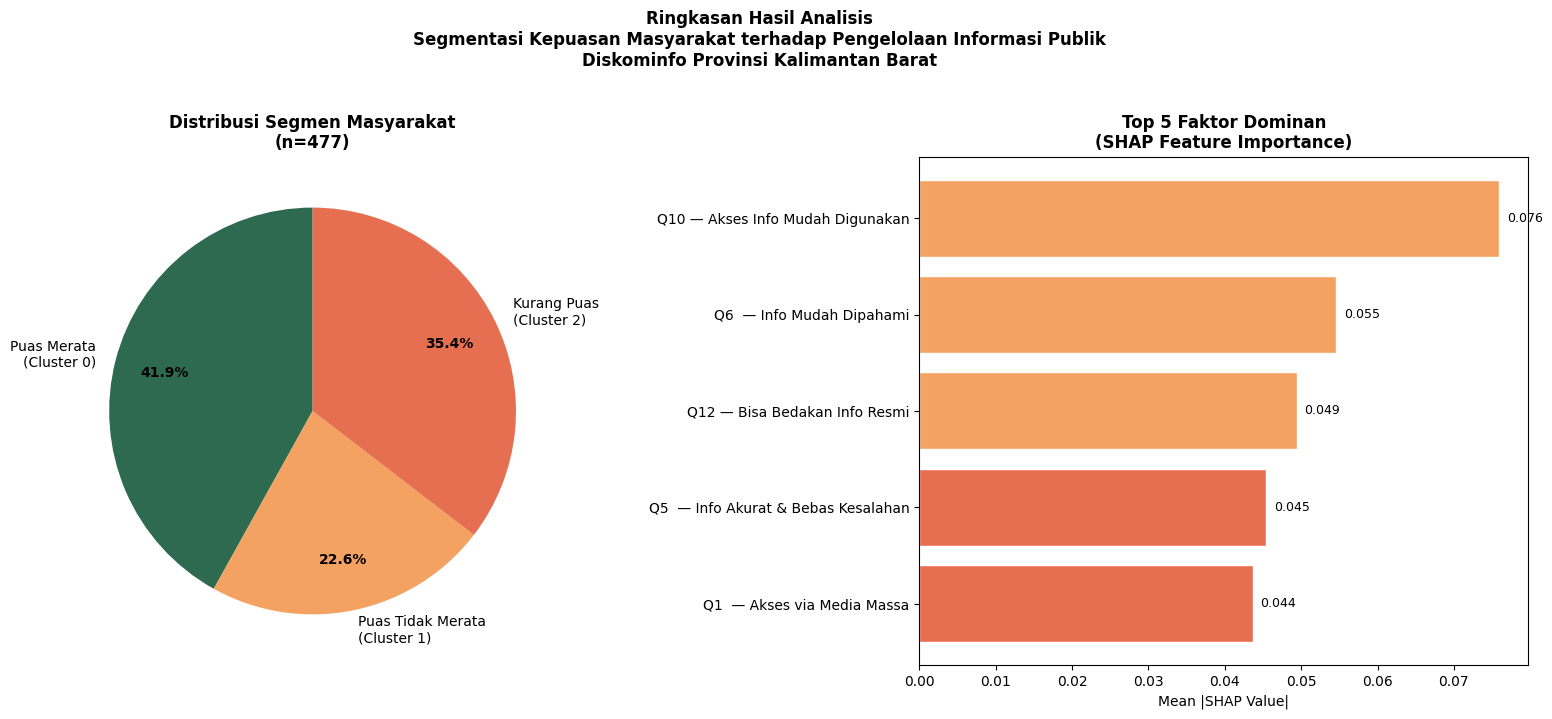

In [ ]:
#===== Visualisasi Final - Summary =====#

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Ringkasan Hasil Analisis\nSegmentasi Kepuasan Masyarakat terhadap Pengelolaan Informasi Publik\nDiskominfo Provinsi Kalimantan Barat',
             fontsize=12, fontweight='bold', y=1.02)

# Kiri — Distribusi cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_labels = ['Puas Merata\n(Cluster 0)',
                  'Puas Tidak Merata\n(Cluster 1)',
                  'Kurang Puas\n(Cluster 2)']
cluster_colors = ['#2D6A4F', '#F4A261', '#E76F51']

wedges, texts, autotexts = axes[0].pie(
    cluster_counts.values,
    labels=cluster_labels,
    autopct='%1.1f%%',
    colors=cluster_colors,
    startangle=90,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Segmen Masyarakat\n(n=477)', fontweight='bold')

# Kanan — Top 5 faktor dominan keseluruhan
top5 = shap_df.tail(5)
bar_colors = ['#E76F51','#E76F51','#F4A261','#F4A261','#F4A261']
axes[1].barh(top5['label'], top5['importance'],
             color=bar_colors, edgecolor='white')
axes[1].set_title('Top 5 Faktor Dominan\n(SHAP Feature Importance)', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')
for i, (val, label) in enumerate(zip(top5['importance'], top5['label'])):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Penjelasan Cell: Ringkasan Hasil Analisis - Distribusi Cluster & Top 5 Faktor Dominan

Cell ini menyajikan ringkasan visual dari hasil analisis:

1.  **Membuat Subplot**: Dua subplot (`axes[0]`, `axes[1]`) dibuat untuk menampilkan dua ringkasan penting.
2.  **Ringkasan Kiri - Distribusi Cluster (Pie Chart)**:
    *   Menghitung `cluster_counts` (jumlah responden di setiap cluster).
    *   Mendefinisikan `cluster_labels` dan `cluster_colors` untuk pie chart.
    *   Membuat pie chart yang menunjukkan proporsi responden di setiap cluster dengan persentase otomatis (`autopct`).
    *   Judul plot menjelaskan distribusi segmen masyarakat.
3.  **Ringkasan Kanan - Top 5 Faktor Dominan Keseluruhan (Bar Chart)**:
    *   Mengambil `top5` fitur paling dominan dari `shap_df` (yang dihitung di cell `6c0UmizUbyYm`).
    *   Menentukan `bar_colors` khusus untuk visualisasi Top 5.
    *   Membuat bar chart horizontal untuk menampilkan `Mean |SHAP Value|` dari Top 5 faktor dominan.
    *   Judul plot menjelaskan tentang Top 5 Faktor Dominan (SHAP Feature Importance).
    *   Menambahkan nilai numerik SHAP di ujung setiap batang.

Visualisasi final ini berfungsi sebagai rangkuman eksekutif, memberikan gambaran cepat tentang ukuran setiap segmen masyarakat dan faktor-faktor terpenting yang mempengaruhi kepuasan secara keseluruhan. Ini sangat berguna untuk presentasi kepada pemangku kepentingan.

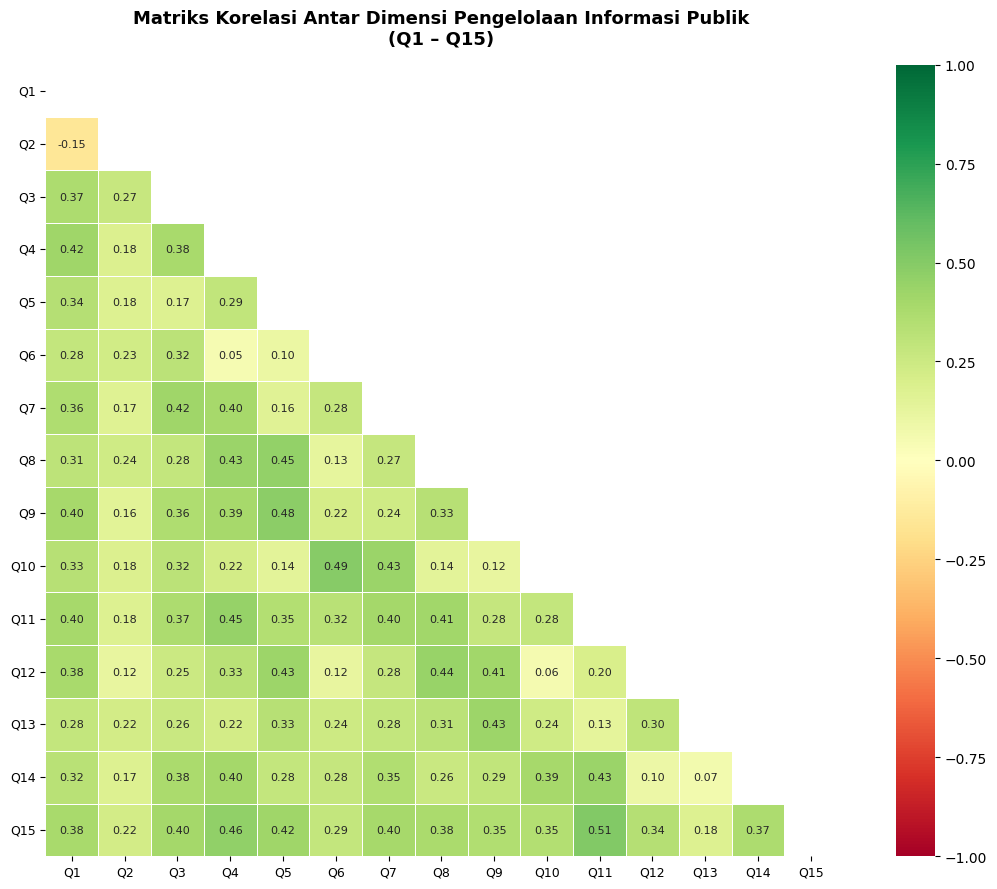

In [ ]:
#===== Heatmap Korelasi Q1-Q15 =====#

plt.figure(figsize=(12, 9))

corr = X[q_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8},
    square=True
)

plt.title('Matriks Korelasi Antar Dimensi Pengelolaan Informasi Publik\n(Q1 – Q15)',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

### Penjelasan Cell: Heatmap Korelasi Antar Dimensi Pengelolaan Informasi Publik

Cell ini memvisualisasikan hubungan korelasi antar pertanyaan survei (Q1-Q15):

1.  **Membuat Figur Plot**: Menginisialisasi ukuran figur untuk heatmap.
2.  **Menghitung Matriks Korelasi**: Menghitung matriks korelasi antara semua kolom `Q` dalam DataFrame `X` menggunakan `X[q_cols].corr()`.
3.  **Membuat Masker Segitiga Atas**: `np.triu(np.ones_like(corr, dtype=bool))` membuat masker yang digunakan untuk menyembunyikan bagian atas segitiga dari heatmap. Ini dilakukan untuk menghindari redundansi karena matriks korelasi adalah simetris.
4.  **Membuat Heatmap**:
    *   Menggunakan `seaborn.heatmap` untuk memvisualisasikan matriks korelasi.
    *   `mask` diterapkan untuk menyembunyikan bagian atas segitiga.
    *   `annot=True` menampilkan nilai korelasi pada setiap sel.
    *   `fmt='.2f'` memformat nilai korelasi hingga 2 desimal.
    *   `cmap='RdYlGn'` menggunakan color map dari merah (korelasi negatif kuat) ke hijau (korelasi positif kuat) dengan kuning di tengah (tidak ada korelasi).
    *   `center=0` mengatur nol sebagai pusat skala warna.
    *   `vmin=-1, vmax=1` memastikan skala warna dari -1 hingga 1.
5.  **Judul dan Label**: Menambahkan judul plot (`Matriks Korelasi Antar Dimensi Pengelolaan Informasi Publik`) dan menyesuaikan ukuran font untuk label sumbu.

Heatmap ini membantu dalam memahami bagaimana satu pertanyaan terkait dengan pertanyaan lainnya. Korelasi positif yang kuat (hijau gelap) berarti responden yang puas dengan satu aspek cenderung puas dengan aspek lainnya, dan sebaliknya untuk korelasi negatif (merah gelap). Ini bisa memberikan wawasan tentang kelompok pertanyaan yang mengukur dimensi serupa.

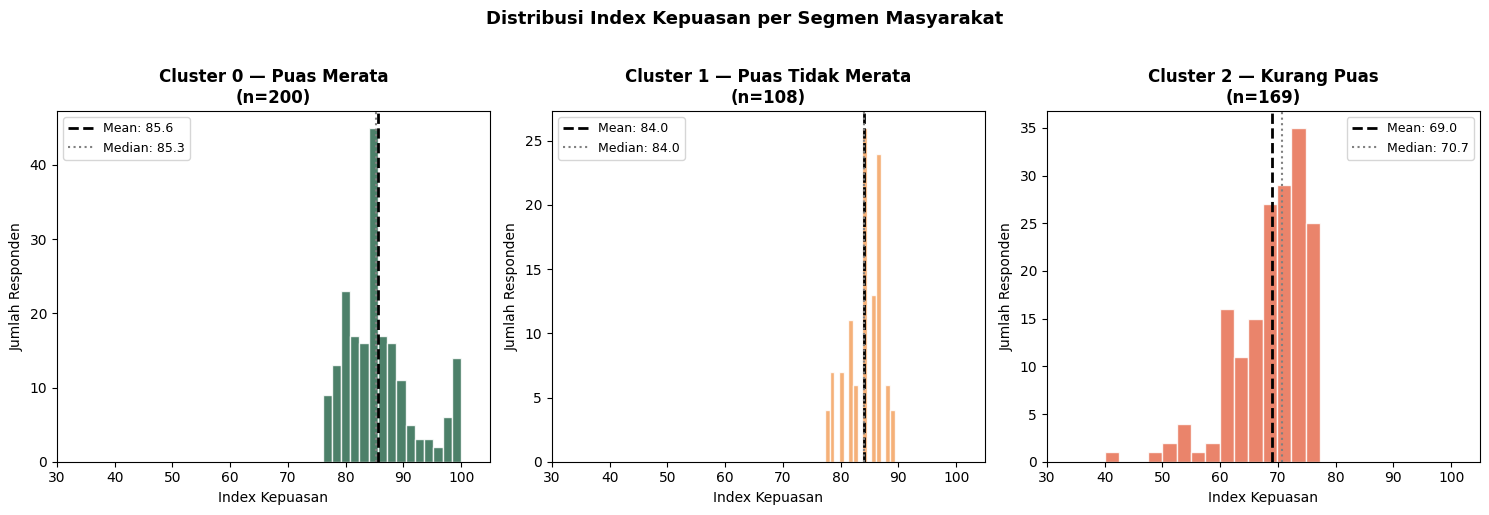

In [ ]:
#===== Distribusi Index per Cluster =====#

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Index Kepuasan per Segmen Masyarakat',
             fontsize=13, fontweight='bold', y=1.02)

cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
cluster_colors = {0: '#2D6A4F', 1: '#F4A261', 2: '#E76F51'}

for i, cluster in enumerate([0, 1, 2]):
    sub = df[df['Cluster'] == cluster]['Index']

    axes[i].hist(sub, bins=15, color=cluster_colors[cluster],
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(sub.mean(), color='black', linewidth=2,
                    linestyle='--', label=f'Mean: {sub.mean():.1f}')
    axes[i].axvline(sub.median(), color='gray', linewidth=1.5,
                    linestyle=':', label=f'Median: {sub.median():.1f}')
    axes[i].set_title(f"Cluster {cluster} — {cluster_names[cluster]}\n(n={len(sub)})",
                      fontweight='bold')
    axes[i].set_xlabel('Index Kepuasan')
    axes[i].set_ylabel('Jumlah Responden')
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(30, 105)

plt.tight_layout()
plt.show()

### Penjelasan Cell: Distribusi Index Kepuasan per Segmen Masyarakat

Cell ini memvisualisasikan distribusi `Index` kepuasan untuk setiap cluster:

1.  **Membuat Subplot per Cluster**: Sebuah figur dengan tiga subplot (`axes[0]`, `axes[1]`, `axes[2]`) dibuat, satu untuk setiap cluster.
2.  **Definisi Nama dan Warna Cluster**: `cluster_names` dan `cluster_colors` digunakan untuk memberikan identitas visual yang konsisten untuk setiap cluster.
3.  **Iterasi per Cluster**: Untuk setiap cluster (0, 1, 2), proses berikut dilakukan:
    *   **Filter Data per Cluster**: DataFrame `df` difilter untuk mendapatkan subset responden yang termasuk dalam cluster tersebut, lalu hanya kolom `Index` yang diambil (`sub`).
    *   **Membuat Histogram**: Plot histogram (`axes[i].hist`) dibuat untuk menampilkan distribusi `Index` kepuasan dalam cluster tersebut, dengan `bins=15` untuk 15 batang.
    *   **Menambahkan Garis Mean dan Median**: Garis vertikal putus-putus ditambahkan untuk menunjukkan nilai rata-rata (`mean`) dan median dari `Index` kepuasan dalam cluster tersebut.
    *   **Judul dan Label Subplot**: Setiap subplot diberikan judul yang jelas (termasuk nama cluster dan jumlah responden) dan label sumbu.
    *   **Batas Sumbu X**: `set_xlim(30, 105)` mengatur batas sumbu X agar konsisten di semua subplot.

Histogram ini secara visual menegaskan perbedaan signifikan dalam tingkat kepuasan antar cluster yang sudah divalidasi secara statistik oleh uji Kruskal-Wallis. Kita dapat melihat bagaimana Cluster 2 ('Kurang Puas') memiliki distribusi `Index` yang bergeser ke kiri (nilai lebih rendah) dibandingkan Cluster 0 dan 1.

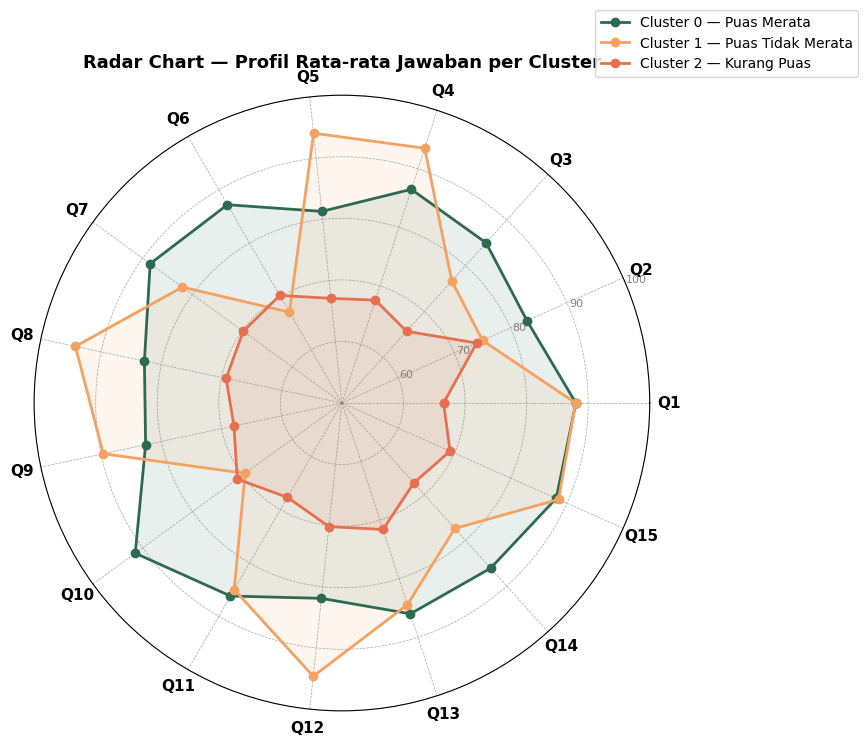

In [ ]:
#===== Radar Chart Profil Cluster =====#


cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
cluster_colors = {0: '#2D6A4F', 1: '#F4A261', 2: '#E76F51'}

# Label pendek untuk radar
labels = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7',
          'Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']

N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cluster in [0, 1, 2]:
    values = cluster_profile.loc[cluster, q_cols].tolist()
    values += values[:1]  # tutup lingkaran

    ax.plot(angles, values, 'o-', linewidth=2,
            label=f"Cluster {cluster} — {cluster_names[cluster]}",
            color=cluster_colors[cluster])
    ax.fill(angles, values, alpha=0.1, color=cluster_colors[cluster])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(50, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.set_yticklabels(['60', '70', '80', '90', '100'], fontsize=8, color='gray')
ax.set_title('Radar Chart — Profil Rata-rata Jawaban per Cluster',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

### Penjelasan Cell: Radar Chart Profil Rata-rata Jawaban per Cluster

Cell ini memvisualisasikan profil rata-rata jawaban untuk setiap cluster menggunakan radar chart, yang ideal untuk membandingkan performa pada berbagai dimensi:

1.  **Mengimpor Library**: Mengimpor `matplotlib.patches` dan `matplotlib.pyplot` untuk plotting, serta `numpy` untuk operasi array.
2.  **Definisi Nama dan Warna Cluster**: `cluster_names` dan `cluster_colors` digunakan untuk memberikan identitas visual yang konsisten.
3.  **Definisi Label (Dimensi)**: `labels` ditetapkan sebagai Q1-Q15, yang akan menjadi sumbu pada radar chart.
4.  **Menghitung Sudut untuk Radar Chart**: `angles` dihitung untuk menempatkan setiap label secara merata di lingkaran. Tambahan `angles[:1]` digunakan untuk 'menutup' grafik agar menjadi poligon tertutup.
5.  **Membuat Figur Plot Polar**: `plt.subplots(subplot_kw=dict(polar=True))` membuat figur dengan sistem koordinat polar, ideal untuk radar chart.
6.  **Iterasi per Cluster**: Untuk setiap cluster (0, 1, 2), proses berikut dilakukan:
    *   **Mengambil Nilai Rata-rata Q**: `values` diambil dari `cluster_profile` untuk cluster saat ini (rata-rata skor Q1-Q15).
    *   **Menutup Poligon**: Tambahan `values[:1]` digunakan untuk menutup poligon pada radar chart.
    *   **Membuat Plot Garis dan Isi**: `ax.plot` menggambar garis untuk profil cluster, dan `ax.fill` mengisi area di bawah garis dengan transparansi (`alpha=0.1`) untuk visualisasi yang lebih jelas.
7.  **Penyesuaian Tampilan Radar Chart**:
    *   `ax.set_xticks` dan `ax.set_xticklabels` mengatur label sumbu (Q1-Q15) dengan ukuran dan gaya font yang sesuai.
    *   `ax.set_ylim` mengatur batas sumbu Y dari 50 hingga 100.
    *   `ax.set_yticks` dan `ax.set_yticklabels` mengatur penanda pada sumbu radial.
    *   `ax.set_title` menambahkan judul plot yang informatif.
    *   `ax.legend` menambahkan legenda untuk mengidentifikasi setiap cluster.
    *   `ax.grid` menambahkan garis grid untuk keterbacaan.

Radar chart ini sangat efektif untuk membandingkan secara visual "bentuk" atau "profil" setiap cluster, menunjukkan dengan cepat dimensi mana yang menjadi kekuatan atau kelemahan relatif untuk masing-masing segmen.

In [ ]:
#===== Analisis per Dimensi =====#


# Pengelompokan dimensi
dimensi = {
    'Jangkauan & Akses'       : ['Q1', 'Q7', 'Q10', 'Q13'],
    'Kualitas Informasi'      : ['Q5', 'Q6', 'Q9', 'Q11'],
    'Retensi & Pemahaman'     : ['Q2', 'Q3', 'Q4'],
    'Kepercayaan & Identitas' : ['Q12'],
    'Utilitas & Dampak'       : ['Q8', 'Q14'],
    'Partisipasi Publik'      : ['Q15'],
}

# Hitung rata-rata skor per dimensi per cluster
rows = []
for dim_name, qs in dimensi.items():
    for cluster in [0, 1, 2]:
        sub = df[df['Cluster'] == cluster][qs].mean().mean()
        rows.append({
            'Dimensi' : dim_name,
            'Cluster' : cluster,
            'Skor'    : round(sub, 2)
        })

dim_df = pd.DataFrame(rows)
print(dim_df.pivot(index='Dimensi', columns='Cluster', values='Skor'))

Cluster                      0      1      2
Dimensi                                     
Jangkauan & Akses        88.50  80.97  69.73
Kepercayaan & Identitas  81.90  94.63  70.18
Kualitas Informasi       84.32  83.94  68.22
Partisipasi Publik       88.10  88.52  69.23
Retensi & Pemahaman      84.80  81.73  69.07
Utilitas & Dampak        84.45  85.83  68.34


### Penjelasan Cell: Analisis Rata-rata Skor per Dimensi

Cell ini mengelompokkan pertanyaan individu (Q1-Q15) ke dalam dimensi yang lebih luas dan menghitung rata-rata skor per dimensi untuk setiap cluster:

1.  **Pengelompokan Dimensi**: Kamus `dimensi` dibuat untuk mengelompokkan pertanyaan (Q1-Q15) ke dalam kategori tematik yang lebih besar seperti 'Jangkauan & Akses', 'Kualitas Informasi', dll.
2.  **Inisialisasi List `rows`**: Sebuah list kosong `rows` disiapkan untuk menyimpan hasil perhitungan.
3.  **Iterasi per Dimensi dan per Cluster**: Melakukan nested loop:
    *   Looping pertama melalui setiap `dim_name` dan daftar pertanyaan (`qs`) yang terkait.
    *   Looping kedua melalui setiap `cluster` (0, 1, 2).
    *   Untuk setiap kombinasi dimensi dan cluster, dihitung rata-rata skor dari pertanyaan-pertanyaan (`qs`) yang ada di dimensi tersebut untuk responden di cluster yang spesifik. Hasilnya dibulatkan ke 2 desimal.
    *   Sebuah dictionary baru (`{'Dimensi', 'Cluster', 'Skor'}`) ditambahkan ke list `rows`.
4.  **Membuat DataFrame `dim_df`**: List `rows` dikonversi menjadi DataFrame `dim_df`.
5.  **Membuat Pivot Table**: `dim_df.pivot(index='Dimensi', columns='Cluster', values='Skor')` digunakan untuk membuat pivot table yang menampilkan rata-rata skor setiap dimensi, dengan dimensi sebagai index dan cluster sebagai kolom. Ini memudahkan perbandingan skor dimensi antar cluster.

Analisis ini membantu menyederhanakan interpretasi dengan melihat performa cluster pada level konseptual yang lebih tinggi (dimensi) daripada pertanyaan individu, memudahkan dalam merumuskan rekomendasi yang lebih strategis.

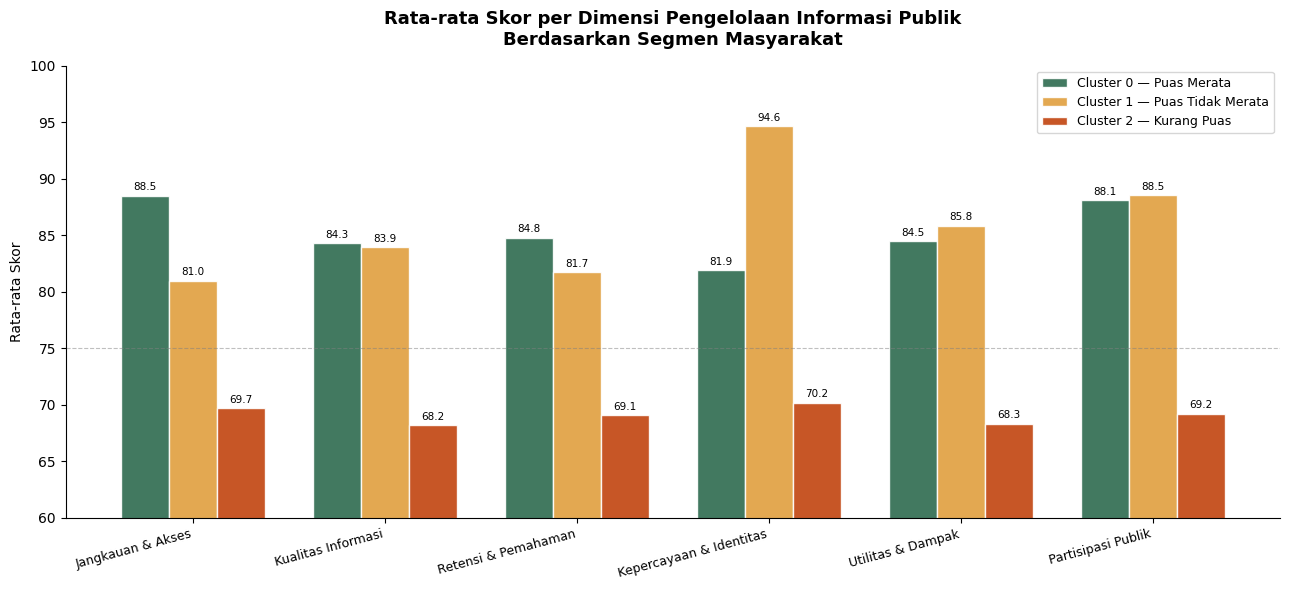

In [ ]:
#===== Visualisasi Analisis per Dimensi =====#

cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
cluster_colors = {0: '#2D6A4F', 1: '#E09F3E', 2: '#C1440E'}

dim_names = list(dimensi.keys())
x = np.arange(len(dim_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

for i, cluster in enumerate([0, 1, 2]):
    vals = [dim_df[(dim_df['Dimensi'] == d) &
                   (dim_df['Cluster'] == cluster)]['Skor'].values[0]
            for d in dim_names]
    bars = ax.bar(x + i * width, vals, width,
                  label=f"Cluster {cluster} — {cluster_names[cluster]}",
                  color=cluster_colors[cluster], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_title('Rata-rata Skor per Dimensi Pengelolaan Informasi Publik\nBerdasarkan Segmen Masyarakat',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Rata-rata Skor')
ax.set_xticks(x + width)
ax.set_xticklabels(dim_names, fontsize=9, rotation=15, ha='right')
ax.set_ylim(60, 100)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(75, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

### Penjelasan Cell: Visualisasi Rata-rata Skor per Dimensi per Segmen Masyarakat

Cell ini memvisualisasikan hasil analisis per dimensi dari `dim_df`:

1.  **Definisi Nama dan Warna Cluster**: `cluster_names` dan `cluster_colors` digunakan untuk konsistensi visual.
2.  **Pengaturan Bar Chart**:
    *   `dim_names` diambil dari kunci kamus `dimensi`.
    *   `x` dibuat sebagai array numerik untuk posisi bar pada sumbu X.
    *   `width` ditentukan untuk lebar setiap bar.
3.  **Membuat Figur dan Subplot**: Membuat figur `fig` dan objek `ax` untuk plot.
4.  **Iterasi per Cluster untuk Plot Bar**: Melakukan iterasi untuk setiap cluster (0, 1, 2):
    *   Mengambil nilai rata-rata skor dimensi (`vals`) untuk cluster saat ini dari `dim_df`.
    *   Membuat bar chart (`ax.bar`) untuk skor dimensi tersebut, dengan sedikit offset (`x + i * width`) agar bar untuk setiap cluster berdampingan.
    *   Menambahkan nilai numerik (`val`) di atas setiap bar untuk pembacaan yang presisi.
5.  **Judul dan Label Plot**: Menetapkan judul plot (`Rata-rata Skor per Dimensi Pengelolaan Informasi Publik Berdasarkan Segmen Masyarakat`) dan label sumbu Y (`Rata-rata Skor`).
6.  **Penyesuaian Sumbu X**: Mengatur posisi label sumbu X (`set_xticks`) dan label aktualnya (`set_xticklabels`) dengan rotasi untuk keterbacaan.
7.  **Batas Sumbu Y**: Menetapkan batas sumbu Y dari 60 hingga 100.
8.  **Legenda**: Menambahkan legenda untuk mengidentifikasi setiap set bar chart sebagai cluster.
9.  **Garis Horizontal Referensi**: Menambahkan garis horizontal putus-putus pada skor 75 sebagai referensi umum untuk 'cukup puas'.

Visualisasi ini memberikan gambaran yang jelas tentang bagaimana setiap cluster berkinerja pada berbagai dimensi pengelolaan informasi publik. Ini membantu Diskominfo untuk melihat dimensi mana yang perlu ditingkatkan untuk segmen tertentu, misalnya, Cluster 'Kurang Puas' memiliki skor rendah di hampir semua dimensi.

### Ringkasan & Rekomendasi

Berikut adalah rangkuman dari hasil analisis segmentasi kepuasan masyarakat terhadap pengelolaan informasi publik Diskominfo Provinsi Kalimantan Barat:

---

#### **Kesimpulan Penelitian**

*   **Data**: 477 responden dari Survei Kepuasan Masyarakat (SKM) Diskominfo Kalbar 2023-2026.
*   **Metode**: K-Means Clustering + SHAP Explainability.

---

#### **Segmentasi Masyarakat (K=3 Cluster)**

*   **Cluster 0 · Puas Merata**: 200 responden (41.9%)
*   **Cluster 1 · Puas Tidak Merata**: 108 responden (22.6%)
*   **Cluster 2 · Kurang Puas**: 169 responden (35.4%)

---

#### **Top 5 Faktor Dominan (Berdasarkan SHAP Feature Importance Keseluruhan)**

1.  **Q10** - Kemudahan Akses Informasi (Nilai SHAP: 0.076)
2.  **Q6** - Kemudahan Memahami Informasi (Nilai SHAP: 0.055)
3.  **Q12** - Kemampuan Mengidentifikasi Informasi Resmi (Nilai SHAP: 0.049)
4.  **Q5** - Akurasi Informasi (Nilai SHAP: 0.045)
5.  **Q1** - Akses via Media Massa (Nilai SHAP: 0.044)

---

#### **Rekomendasi untuk Diskominfo Provinsi Kalimantan Barat**

1.  **Prioritaskan Kemudahan Akses**: Tingkatkan kemudahan akses ke platform informasi publik, terutama SIKEDIP (terkait **Q10**).
2.  **Perbaiki Keterbacaan & Kejelasan**: Pastikan konten informasi mudah dipahami oleh berbagai kalangan masyarakat (terkait **Q6**).
3.  **Perkuat Kredibilitas Informasi**: Edukasi masyarakat untuk membedakan informasi resmi dan hoaks, serta perkuat branding informasi resmi (terkait **Q12**).
4.  **Jaga Akurasi Data**: Perketat proses verifikasi dan validasi informasi sebelum dipublikasikan untuk menjaga akurasi (terkait **Q5**).
5.  **Optimalkan Jangkauan Media Massa**: Manfaatkan berbagai saluran media massa secara efektif untuk menyebarkan informasi (terkait **Q1**).

---

#### **Temuan Utama Tambahan**

*   **Demografi Bukan Penentu Utama**: Karakteristik demografi tidak secara signifikan membedakan tingkat kepuasan antar cluster; pola penilaian terhadap pertanyaanlah yang menjadi pembeda.
*   **Segmen 'Kurang Puas' Signifikan**: 35.4% masyarakat masih tergolong 'Kurang Puas', menunjukkan perlunya intervensi terarah.
*   **Akses Lebih Penting dari Konten**: Kemudahan akses informasi cenderung memiliki pengaruh yang lebih besar terhadap kepuasan dibandingkan dengan kualitas konten itu sendiri.
*   **Faktor Pendorong Kepuasan Berbeda**: Setiap cluster memiliki faktor-faktor dominan yang berbeda yang memengaruhi kepuasan mereka, menandakan perlunya pendekatan komunikasi dan pelayanan yang disesuaikan untuk setiap segmen.